In [ ]:
from typing import TypedDict
class SomeState(TypedDict):
    att1: str
    att2: str
# This is basically defining the structure of the state that will move through your LangGraph.
# You're importing TypedDict from Python's typing module. TypedDict allows you to define:
# What keys should a dictionary have, and what type of value should each key contain?
# The state carries information from one node to another.
# TypedDict doesn't create an actual dictionary by itself.It mainly tells Python/LangGraph:
# "This is the expected structure of my state."
# sp basically the code means:
# "My state is expected to be a dictionary containing att1 and att2, and both values should be strings."
# That's the main idea you need before moving to the next LangGraph code.
#SomeState is a name you choose.att1 and att2 These are dictionary key names / state field names
# you may give any meaningful names as per requirement
# class FinancingState(TypedDict):
#     customer_type: str
#     vehicle_type: str
#     monthly_income: str
#     recommendation: str
# SomeState, att1, and att2 are names chosen by the developer; TypedDict and str are Python constructs/types.

In [ ]:
def some_function(state: SomeState):
    state['att1'] = "Value Changed by node some_function()"
    return state
# # This function is basically a LangGraph node that receives the current state, changes one field, and sends the updated state forward.
# state: SomeState -It tells Python: "I expect state to follow the structure defined by SomeState
# next line is simply updating the att1 values from blank to "valye changed by node some_function"
# return state means - The function sends the updated state back.
# This function says: "Take the current state, change the value of att1, and return the updated stat

In [ ]:
# One subtle but important point: state is not a variable that you created beforehand in this code.
#  LangGraph will supply it when it executes the node.
# That's why understanding the State → Node → Updated State flow is key to understanding LangGraph.

In [ ]:
!pip install -U langgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 248.9/248.9 kB 6.0 MB/s eta 0:00:00
  Attempting uninstall: langgraph
    Found existing installation: langgraph 1.2.9
    Uninstalling langgraph-1.2.9:
      Successfully uninstalled langgraph-1.2.9


In [ ]:
# StateGraph = the overall workflow
# Node       = one step in the workflow
# State      = information being passed between steps

In [ ]:
from langgraph.graph import StateGraph
#StateGraph is a LangGraph class that lets you create a graph/workflow where state moves between nodes.

In [ ]:
graph = StateGraph(SomeState)
#"Create a graph whose state follows the structure defined by SomeState."

In [ ]:
graph.add_node('node1', some_function)
# "Add a node called node1 to my graph, and when this node runs, execute some_function."

In [ ]:
# so till this point what we did
# SomeState
#    │
#    │ defines the structure
#    ▼
# StateGraph
#    │
#    │ contains
#    ▼
#  node1
#    │
#    │ executes
#    ▼
# some_function()
#    │
#    │ changes
#    ▼
# att1

# At this point, you have created the graph and added a node,
# but you haven't told LangGraph how the graph should START and where it should GO next.

In [ ]:
from langgraph.graph.state import END
# END is a special marker provided by LangGraph.

In [ ]:
graph.add_edge("node1", END)
# After node1 finishes, stop the graph.

In [ ]:
graph.set_entry_point('node1')
# "Start my graph from node1." Tell LangGraph where to start

In [ ]:
compiled_graph = graph.compile()

# compile() basically says: # "Okay, take this graph definition and turn it into an executable LangGraph application."
# After compilation, compiled_graph is what you actually use to run the workflow.

In [ ]:
from IPython.display import Image

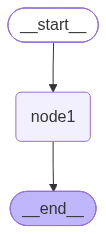

In [ ]:
Image(compiled_graph.get_graph().draw_mermaid_png())

In [ ]:
# the key distinction to remember:

# add_node() → What work should be done?
# add_edge() → What happens after this node?
# set_entry_point() → Where do we start?
# compile() → Make the defined graph executable
# invoke() → Actually run it

In [ ]:
result = compiled_graph.invoke({
    "att1": "Original Value",
    "att2": "Hello"
})

# execute the graphs  and next line print result

In [ ]:
print(result)

{'att1': 'Value Changed by node some_function()', 'att2': 'Hello'}


#MULTI NODE EXAMPLE

In [ ]:
# ANOTHER EXAMPLE

In [ ]:
class State(TypedDict):
    graph_state: str

In [ ]:
def first_node(state):
    print("This is my first node")
    return {"graph_state": state['graph_state'] + "Hi, I am traveling "}

def second_node(state):
    print("This is my second node")
    return {"graph_state": state['graph_state'] + "United Kigdom - London"}

def third_node(state):
    print("This is my third node")
    return {"graph_state": state['graph_state'] + "United State of America (USA)"}

In [ ]:
# The important LangGraph concept
#              STATE
#                ↓
#          ┌────────────┐
#          │ first_node │
#          └──────┬─────┘
#                 │
#          updated STATE
#                 ↓
#         ┌─────────────┐
#         │ second_node │
#         └──────┬──────┘
#                │
#         updated STATE
#                ↓
#         ┌────────────┐
#         │ third_node │
#         └──────┬─────┘
#                │
#                ↓
#               END

# each node: receives state → does something → returns updated state

In [ ]:
# in case in second node langrpah updates only 1 field  - thats how flot will be
# Initial State
# ┌─────────────────────────┐
# │ customer_name = Rahul   │
# │ vehicle_type = CNG      │
# │ income = 40,000         │
# └─────────────────────────┘
#              ↓
#         first_node
#              ↓
#      returns only:
#      vehicle_type = EV
#              ↓
# LangGraph merges update
#              ↓
# ┌─────────────────────────┐
# │ customer_name = Rahul   │ ← retained
# │ vehicle_type = EV       │ ← updated
# │ income = 40,000         │ ← retained
# └─────────────────────────┘
#              ↓
#        second_node

In [ ]:
# The one mental model to keep in your head for LangGraph is:

# Initial state → Node → updated state → next node → updated state → next node → END

# And:

# invoke() → gives the initial state
# state inside a node → receives the current full state
# return {...} → tells LangGraph what to update
# LangGraph → merges the update and carries the state forward

In [ ]:
# Logic
import random
from typing import Literal

def decide_location(state) -> Literal["second_node", "third_node"]:
    graph_state = state['graph_state']
    if random.random() < 0.5:
        return "second_node"
    else:
        return "third_node"

In [ ]:
# explanation for above code
# Python's random module lets us generate random numbers. Here we're going to randomly decide which node should run next.
# Literal is used to say: "This function is allowed to return only these specific values."
# Here: Literal["second_node", "third_node"] means:
# The function should return either "second_node" or "third_node". It is basically telling us what the possible routes are.

# function is a routing/decision function. It receives the current state:
#  It receives the current state:  state  and decides:
# Should I go to second_node?
#              OR
# Should I go to third_node?
# Notice this function is not changing the state.  It is deciding where the graph should go next.

# random.random() This generates a random number between 0 and 1. and based on value decide which node to go
#              decide_location
#                     │
#              random number
#                     │
#           ┌─────────┴─────────┐
#           │                   │
#        < 0.5               >= 0.5
#           │                   │
#           ▼                   ▼
#     second_node          third_node



In [ ]:
# so the two functions that we wrote here
# Normal node
# def first_node(state):
#     return {
#         "graph_state": state["graph_state"] + "Hello"
#     }

# Its job: Process/update state.

# Routing function
# def decide_location(state):
#     return "second_node"

# Its job: Decide which node executes next.
#                  START
#                    │
#                    ▼
#               first_node
#                    │
#                    ▼
#           decide_location
#              /          \
#             /            \
#            ▼              ▼
#     second_node       third_node
#            \              /
#             \            /
#              ▼          ▼
#                   END
# This is called conditional routing.

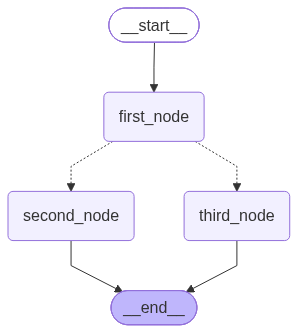

In [ ]:
# Building LangGraph Model (connect with node, edge and end)

from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

builder = StateGraph(State)
builder.add_node("first_node", first_node)
builder.add_node("second_node", second_node)
builder.add_node("third_node", third_node)

builder.add_edge(START, 'first_node')
builder.add_conditional_edges("first_node", decide_location)
builder.add_edge("second_node", END)
builder.add_edge("third_node", END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
# StateGraph → to create the graph
# START → special starting point
# END → special ending point
# Image, display → to display the graph visually in Jupyter/Colab
# builder = StateGraph(State) Create a LangGraph whose state follows the structure of State.

# start from first node and then
# builder.add_conditional_edges("first_node", decide_location) This means:
# After first_node finishes, don't automatically go to one fixed node. Instead, call decide_location() to decide where to go.
# after this assign END and draw the map

In [ ]:
graph.invoke({"graph_state": "Hi, Iam Batman, "})

This is my first node
This is my second node


{'graph_state': 'Hi, Iam Batman, Hi, I am traveling United Kigdom - London'}

In [ ]:
graph.invoke({"graph_state": "Hi, my name is Andrew Ng, "})

This is my first node
This is my third node


{'graph_state': 'Hi, my name is Andrew Ng, Hi, I am traveling United State of America (USA)'}

In [ ]:
graph.invoke({"graph_state": "Hi, my name is priyanka chopra, "})

This is my first node
This is my third node


{'graph_state': 'Hi, my name is priyanka chopra, Hi, I am traveling United State of America (USA)'}